# 08 — Spartan Arena validation

**What this notebook does**

Load the most recent arena run from disk (or from TimescaleDB), audit
the artifact pipeline produced everything we expect, and visualise the
two pieces a reviewer cares about: per-trajectory equity curves and the
distribution of cross-modal attention weights.

**Why this notebook exists**

The Spartan Arena produces five kinds of artifacts:

| Artifact | Where | What it tells us |
|---|---|---|
| `DecisionRecord`s | TimescaleDB + `decisions.jsonl` | Every agent action with full attribution |
| `.npy` super-states | `<run>/states/<traj>/<step>.npy` | The 224-d Chimera state at each step |
| `DivergencePoint`s | TimescaleDB | Steps where trajectories' fates diverged |
| `CounterfactualPair`s | JSONL + `bc_dataset.npz` | Training-grade `(state, good, bad)` triplets |
| `RunSummary` | end-of-run narrative | Human-readable post-mortem |

This notebook reads them back, asserts the cross-trajectory shapes are
sane (same step count, consistent action dimensionality), and produces
the plots that go into reviewer reports.

**Prerequisites**

You must have run the arena at least once. The fastest path is:

```bash
python scripts/run_arena.py \
    --ticker AAPL --start 2024-01-01 --end 2024-01-02 \
    --n-trajectories 3 --n-steps 50 --output-dir ./artifacts/arena
```

This produces a self-contained run against synthetic data and an
untrained policy — perfect for plumbing validation.


## 1. Setup

Imports are scoped to read-side only — we never call a model from this
notebook, so the heavy `torch`/`captum` imports are kept out of the
hot path.

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from backend.config.settings import get_settings
from backend.simulation.arena.schemas import (
    ArenaRunMetadata,
    DecisionRecord,
)
from backend.simulation.xai.run_summarizer import summarize_run

## 2. Locate the most recent run

Each arena run produces a directory under `Settings.arena.artifact_dir`
named after its UUID. We pick the most recently-modified one. If there
are no runs, the assertion below halts the notebook so the reader knows
to launch one first.

In [2]:
# Resolve the artifact root relative to the project root, not the
# notebook's current working directory. This lets the notebook be
# launched from `notebooks/`, the repo root, or anywhere else.
project_root = Path.cwd()
while not (project_root / "pyproject.toml").exists() and project_root != project_root.parent:
    project_root = project_root.parent

settings_dir = Path(get_settings().arena.artifact_dir)
artifact_root = settings_dir if settings_dir.is_absolute() else (project_root / settings_dir)
artifact_root = artifact_root.resolve()
print(f"Looking under: {artifact_root}")

run_dirs = sorted(
    [p for p in artifact_root.iterdir() if p.is_dir() and (p / "decisions.jsonl").exists()],
    key=lambda p: p.stat().st_mtime,
    reverse=True,
)
assert run_dirs, (
    f"No runs found under {artifact_root}. Run `python scripts/run_arena.py ...` first."
)

latest = run_dirs[0]
print(f"Loading run: {latest.name}")
print(f"  Modified: {pd.Timestamp(latest.stat().st_mtime, unit='s')}")

Looking under: /home/pyros05/Escritorio/lumina_project/artifacts/arena
Loading run: 9ba8f937-ab18-4e2e-8491-454ddefca0eb
  Modified: 2026-06-01 06:32:17.395206928


## 3. Load all decision records

`decisions.jsonl` is append-only: one JSON object per line, each one a
serialised `DecisionRecord`. We validate them against the Pydantic
schema as we load — that's the contract guarantee that downstream
operations (the divergence analyser, the BC dataset writer) can rely
on the shape they see.


In [3]:
records: list[DecisionRecord] = []
with (latest / "decisions.jsonl").open("r", encoding="utf-8") as fh:
    for line in fh:
        records.append(DecisionRecord.model_validate_json(line))

print(f"Loaded {len(records)} decisions")

# Sanity checks: every trajectory should have produced the same number of
# decisions (because the runner is step-locked). When trajectories
# terminated early (drawdown limit), counts will differ — but they
# should all be close.
counts = pd.Series([r.trajectory_id for r in records]).value_counts().sort_index()
print("Decisions per trajectory:")
print(counts.to_string())

Loaded 1990 decisions
Decisions per trajectory:
0    199
1    199
2    199
3    199
4    199
5    199
6    199
7    199
8    199
9    199


## 4. Flatten into a DataFrame

The wide-format frame is much easier to slice/plot than the list of
Pydantic objects. We keep only the columns we actually use; the
attribution payload stays in the Pydantic objects so we don't lose
structure.

In [4]:
df = pd.DataFrame(
    [
        {
            "trajectory_id": r.trajectory_id,
            "step_index": r.step_index,
            "sim_timestamp": r.sim_timestamp,
            "action_kind": r.action_kind.value,
            "direction": r.action_vector[0],
            "urgency": r.action_vector[1],
            "sizing": r.action_vector[2],
            "stop": r.action_vector[3],
            "confidence": r.confidence,
            "uncertainty": r.uncertainty,
            "realized_reward": r.realized_reward or 0.0,
            "cm_price": r.attribution.cross_modal.price,
            "cm_news": r.attribution.cross_modal.news,
            "cm_graph": r.attribution.cross_modal.graph,
        }
        for r in records
    ]
)
print(f"DataFrame shape: {df.shape}")
df.head()

DataFrame shape: (1990, 14)


,trajectory_id,step_index,sim_timestamp,action_kind,direction,urgency,sizing,stop,confidence,uncertainty,realized_reward,cm_price,cm_news,cm_graph
0,0,0,1900-01-01 00:00:00+00:00,HOLD,-0.219590,0.000422,0.326190,-0.673870,0.581030,0.418970,0.0,0.333333,0.333333,0.333333
1,1,0,1900-01-01 00:00:00+00:00,HOLD,-0.103946,-0.595923,0.147198,-0.064384,0.495035,0.504965,0.0,0.333333,0.333333,0.333333
2,2,0,1900-01-01 00:00:00+00:00,HOLD,-0.672796,-0.643916,-0.297080,0.206214,0.608337,0.391663,0.0,0.333333,0.333333,0.333333
3,3,0,1900-01-01 00:00:00+00:00,HOLD,-0.184246,-0.343472,-0.057916,0.187108,0.531410,0.468590,0.0,0.333333,0.333333,0.333333
4,4,0,1900-01-01 00:00:00+00:00,HOLD,-0.333652,-0.287269,0.327234,-0.005871,0.463310,0.536690,0.0,0.333333,0.333333,0.333333


## 5. Plot the equity curves

Each trajectory shares the same calendar but diverges in actions because
its Monte Carlo seed differs. We plot the *cumulative realized reward*
as the per-trajectory equity proxy. With an untrained policy the
curves bounce around zero; with a trained policy they should fan out
based on how well the policy handles each seed's perturbations.

The red dotted line marks zero — equity-positive trajectories sit
above it.

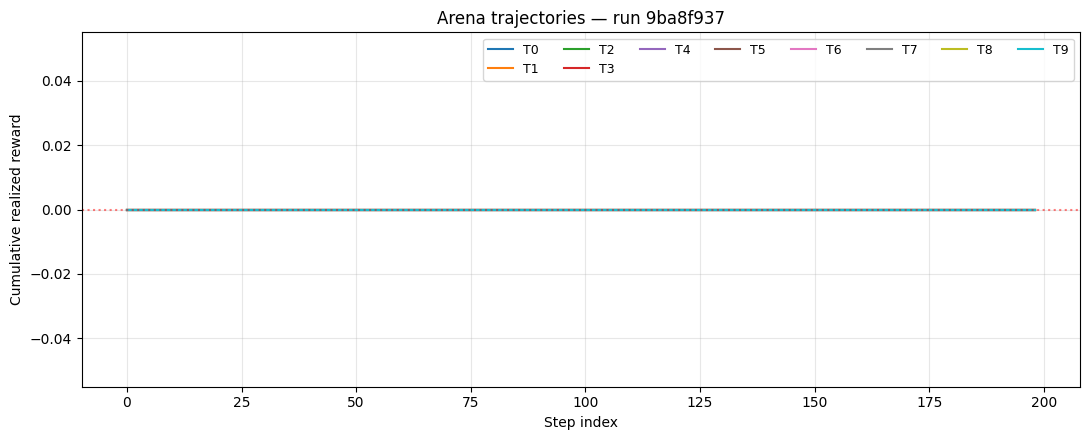

In [5]:
fig, ax = plt.subplots(figsize=(11, 4.5))
for tid, g in df.groupby("trajectory_id"):
    g = g.sort_values("step_index")
    ax.plot(g.step_index, g.realized_reward.cumsum(), label=f"T{tid}", linewidth=1.5)

ax.axhline(0, color="red", linestyle=":", alpha=0.5)
ax.set_xlabel("Step index")
ax.set_ylabel("Cumulative realized reward")
ax.set_title(f"Arena trajectories — run {latest.name[:8]}")
ax.legend(loc="best", ncol=min(8, df.trajectory_id.nunique()), fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Cross-modal weight distributions

The Chimera fusion block decides, at every step, which of the three
input modalities — **price**, **news**, **graph** — to weight most
heavily. Healthy traces show all three weights being used; pathological
traces collapse to one modality forever (a sign the encoder pipeline
returned a degenerate output).

We expect the histograms to be roughly centred around 0.33 with some
spread. A modality stuck near 0.0 or 1.0 across the run is a red flag.

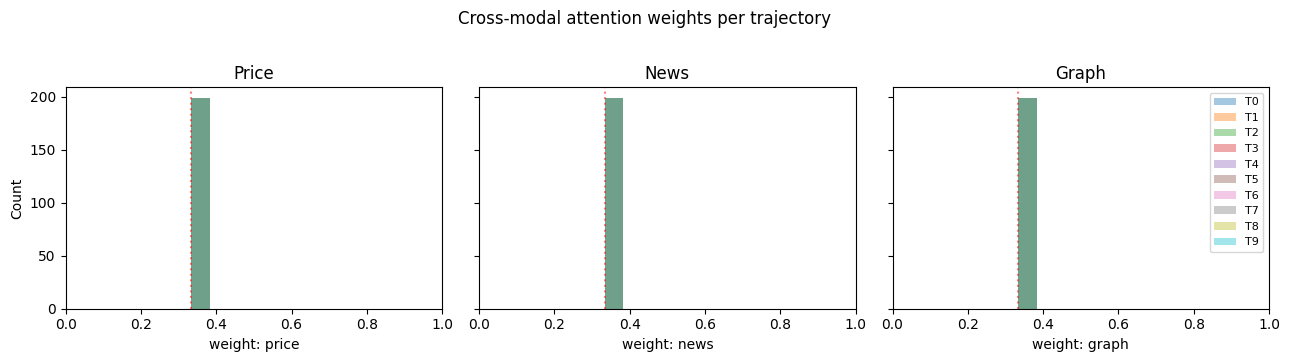

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5), sharey=True)
for col, ax in zip(("cm_price", "cm_news", "cm_graph"), axes, strict=True):
    for tid, g in df.groupby("trajectory_id"):
        ax.hist(g[col], bins=20, alpha=0.4, label=f"T{tid}")
    ax.set_xlim(0, 1)
    ax.axvline(1 / 3, color="red", linestyle=":", alpha=0.5)
    ax.set_xlabel(col.replace("cm_", "weight: "))
    ax.set_title(col.split("_")[1].capitalize())
axes[0].set_ylabel("Count")
axes[-1].legend(fontsize=8, loc="best")
fig.suptitle("Cross-modal attention weights per trajectory", y=1.02)
plt.tight_layout()
plt.show()

## 7. Step-level action divergence

This is the cheap, in-notebook proxy for the divergence analyser. For
every step, we measure the spread (max − min) of the `direction`
component across trajectories. A high spread means trajectories made
qualitatively different bets at the same calendar moment — which is
the regime the arena is designed to surface.

This is *not* the same as the production divergence pipeline (which
also checks subsequent Sharpe), but it identifies the same candidate
moments and is much cheaper to compute.

In [7]:
spread = (
    df.groupby("step_index")["direction"]
    .agg(lambda s: float(s.max() - s.min()))
    .sort_values(ascending=False)
)
print(f"Mean direction spread: {spread.mean():.3f}")
print(f"Max  direction spread: {spread.max():.3f}")
print()
print("Top 10 most-divergent steps:")
print(spread.head(10).to_frame("direction_range"))

Mean direction spread: 0.978
Max  direction spread: 1.625

Top 10 most-divergent steps:
            direction_range
step_index                 
46                 1.624903
68                 1.472377
178                1.468988
71                 1.438537
34                 1.430799
33                 1.413628
101                1.408372
59                 1.396008
116                1.374465
130                1.367597


## 8. Run summary

Reuse the production `run_summarizer` to render the same narrative the
API endpoint serves at `/arena/runs/{run_id}/summary`. This double-checks
that the schema we just loaded round-trips through the summariser
without crashes.


In [8]:
decisions_by_traj: dict[int, list[DecisionRecord]] = {}
for r in records:
    decisions_by_traj.setdefault(r.trajectory_id, []).append(r)

# Reconstruct a minimal ArenaRunMetadata from the records.
n_traj = df.trajectory_id.nunique()
mc_seeds = [decisions_by_traj[t][0].mc_seed for t in sorted(decisions_by_traj)][:n_traj]
# The schema requires >= 3 seeds; pad if the smoke run used fewer.
while len(mc_seeds) < 3:
    mc_seeds.append(0)

meta = ArenaRunMetadata(
    run_id=records[0].run_id,
    ticker=records[0].ticker,
    start_date=min(r.sim_timestamp for r in records),
    end_date=max(r.sim_timestamp for r in records),
    n_trajectories=max(3, n_traj),
    mc_seeds=mc_seeds,
)

summary = summarize_run(meta, decisions_by_traj, divergences=[])
print(summary.narrative)
print()
print(f"summary_method = {summary.summary_method}")

Run 9ba8f937-ab18-4e2e-8491-454ddefca0eb | ticker=AAPL | 1900-01-01 -> 1900-01-01 | N=10 trajectories
Performance: best=T0 (+0.00) | worst=T0 (+0.00) | mean=+0.00 | std=0.00
Divergences: total=0 | pivotal=0
Modality lean: most-frequent dominant = price (1990/1990 steps) | avg weights = price 0.33, news 0.33, graph 0.33

summary_method = template


## 9. BC dataset (if produced)

When the feedback pipeline has run, a `bc_dataset.npz` file sits at the
artifact root. It contains `(state, action)` pairs for the next BC
training phase — high-confidence counterfactual pairs are duplicated to
weight them more heavily in the gradient.

This cell shows the dataset's shape and a quick histogram of the
*target* direction (action[0]). A healthy dataset has actions spanning
both buy (>0) and sell (<0) — the arena explicitly captures both.

BC dataset:
  states : (1492, 260)  dtype=float32
  actions: (1492, 4)  dtype=float32


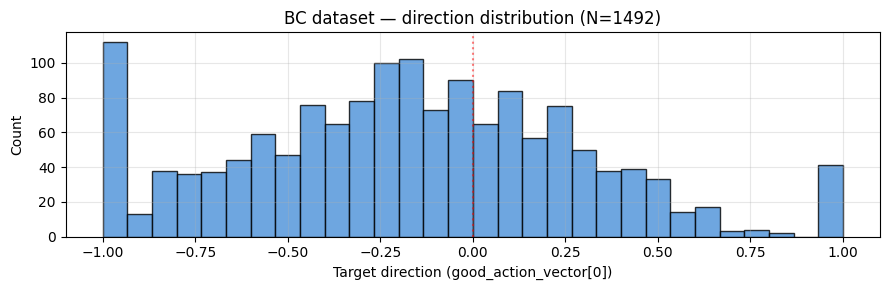

In [9]:
bc_path = artifact_root / "bc_dataset.npz"
if bc_path.exists():
    bc = np.load(bc_path)
    states = bc["states"]
    actions = bc["actions"]
    print("BC dataset:")
    print(f"  states : {states.shape}  dtype={states.dtype}")
    print(f"  actions: {actions.shape}  dtype={actions.dtype}")

    fig, ax = plt.subplots(figsize=(9, 3))
    ax.hist(actions[:, 0], bins=30, color="#4a90d9", edgecolor="black", alpha=0.8)
    ax.set_xlabel("Target direction (good_action_vector[0])")
    ax.set_ylabel("Count")
    ax.set_title(f"BC dataset — direction distribution (N={len(actions)})")
    ax.axvline(0, color="red", linestyle=":", alpha=0.5)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print(f"No BC dataset at {bc_path} — pipeline did not run feedback.replay_buffer_writer")
    print("Run the feedback pipeline once to populate it.")

## 10. Sanity assertions

Final acceptance checks. If any of these fail the run was malformed and
the artifacts should not feed back into training.

In [10]:
# All trajectories produced at least *some* decisions.
assert df.trajectory_id.nunique() >= 2, "Need at least 2 trajectories for divergence analysis."

# Every action_vector has exactly 4 components — the canonical Lumina
# action space (direction, urgency, sizing, stop).
assert df[["direction", "urgency", "sizing", "stop"]].notna().all().all()

# Cross-modal weights sum to ~1 at every step (softmax property).
totals = df[["cm_price", "cm_news", "cm_graph"]].sum(axis=1)
assert ((totals - 1.0).abs() < 1e-3).all(), (
    f"Cross-modal weights do not sum to 1 in {(~((totals - 1.0).abs() < 1e-3)).sum()} rows"
)

# Confidence in [0, 1] is enforced by the Pydantic schema, but it costs
# nothing to re-verify after the round-trip.
assert df.confidence.between(0.0, 1.0).all()
assert df.uncertainty.between(0.0, 1.0).all()

print("PASS — arena run artifacts are well-formed.")

PASS — arena run artifacts are well-formed.
